In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import adfuller

In [44]:
df = pd.read_excel('ngshistory.xls')
df = df.rename(columns = {'Week ending': ''})
df = df.set_index('')
df.index = pd.to_datetime(df.index)
df = df.drop(columns = 'Source')

df

,East Region,Midwest Region,Mountain Region,Pacific Region,South Central Region,Salt,NonSalt,Total Lower 48
,,,,,,,,
2010-01-01,769,900,195,268,985,159,826,3117
2010-01-08,703,820,185,257,886,123,763,2850
2010-01-15,642,750,176,246,793,91,702,2607
2010-01-22,616,710,171,235,789,102,687,2521
2010-01-29,582,661,164,221,779,108,671,2406
...,...,...,...,...,...,...,...,...
2025-12-26,736,865,264,307,1203,343,859,3375
2026-01-02,697,821,256,304,1178,343,835,3256
2026-01-09,664,790,251,302,1178,355,823,3185


In [52]:
diff_df = pd.DataFrame()
diff_df.set_index(diff_df.index)

for i in df.columns:
    
    diff_df[i + ' Difference'] = df[i] - df[i].shift(1)

diff_df = diff_df.dropna()

diff_df.head()

,East Region Difference,Midwest Region Difference,Mountain Region Difference,Pacific Region Difference,South Central Region Difference,Salt Difference,NonSalt Difference,Total Lower 48 Difference
,,,,,,,,
2010-01-08,-66.0,-80.0,-10.0,-11.0,-99.0,-36.0,-63.0,-267.0
2010-01-15,-61.0,-70.0,-9.0,-11.0,-93.0,-32.0,-61.0,-243.0
2010-01-22,-26.0,-40.0,-5.0,-11.0,-4.0,11.0,-15.0,-86.0
2010-01-29,-34.0,-49.0,-7.0,-14.0,-10.0,6.0,-16.0,-115.0
2010-02-05,-59.0,-57.0,-7.0,-10.0,-60.0,-13.0,-47.0,-192.0


Text(0.5, 1.0, 'Total Lower 48')

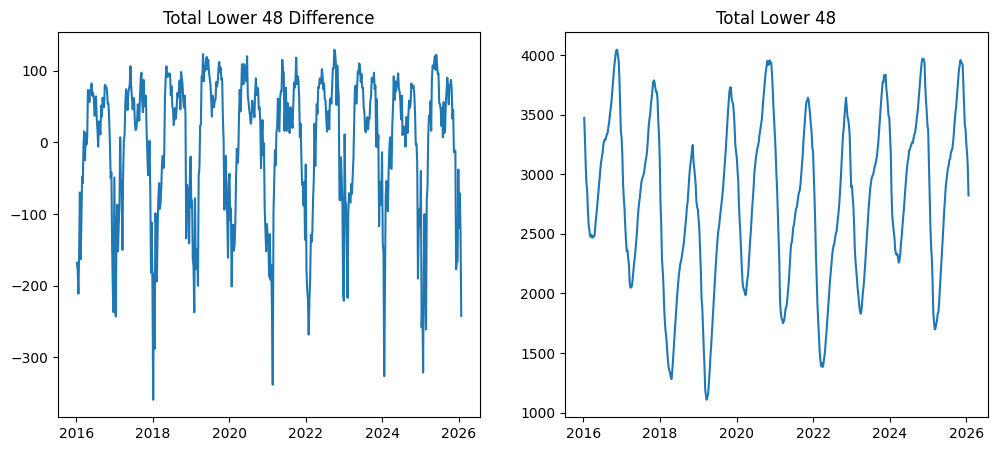

In [60]:
filtered_diff_df = diff_df[diff_df.index > '2016-01-01']
filtered_df = df[df.index > '2016-01-01']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(filtered_diff_df['Total Lower 48 Difference'])
ax1.set_title('Total Lower 48 Difference')

ax2.plot(filtered_df['Total Lower 48'])
ax2.set_title('Total Lower 48')

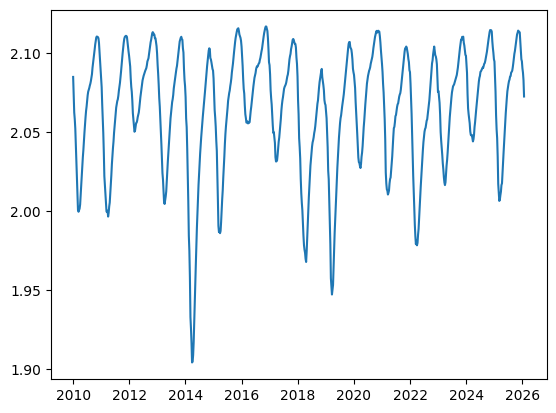

In [76]:
log_df = pd.DataFrame()
log_df['x'] = np.log(np.log(df['Total Lower 48']))

plt.plot(log_df['x'])
plt.show()

In [63]:
model = AutoReg(df['Total Lower 48'], lags = 10, old_names = False)
results = model.fit()

print(results.summary())

                            AutoReg Model Results                             
Dep. Variable:         Total Lower 48   No. Observations:                  839
Model:                    AutoReg(10)   Log Likelihood               -4301.912
Method:               Conditional MLE   S.D. of innovations             43.395
Date:                Wed, 04 Feb 2026   AIC                           8627.825
Time:                        17:33:05   BIC                           8684.467
Sample:                    03-12-2010   HQIC                          8649.547
                         - 01-23-2026                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 59.0746      8.607      6.864      0.000      42.206      75.943
Total Lower 48.L1      1.5689      0.035     45.008      0.000       1.501       1.637
Total Lower 48.L2   

/Users/christianlimb/Desktop/ng_storage_SARIMA/.venv/lib/python3.9/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [64]:
ar_params = results.params[1:]
print(ar_params)

Total Lower 48.L1     1.568885
Total Lower 48.L2    -0.440541
Total Lower 48.L3    -0.057482
Total Lower 48.L4    -0.007791
Total Lower 48.L5     0.035068
Total Lower 48.L6    -0.162247
Total Lower 48.L7     0.031505
Total Lower 48.L8    -0.005857
Total Lower 48.L9    -0.046617
Total Lower 48.L10    0.063803
dtype: float64


In [ ]:
# These are the coefficients and we are concat the ar_params with 1 in front
poly_coeffs = np.concatenate([[1], -ar_params])
print(poly_coeffs)

[ 1.         -1.56888548  0.44054092  0.05748218  0.00779088 -0.03506789
  0.16224682 -0.03150517  0.00585683  0.04661701 -0.06380252]


In [67]:
roots = np.roots(poly_coeffs)
print(f"\nCharacteristic polynomial roots:")
print(roots)

print(f"\nAbsolute values of roots:")
print(np.abs(roots))


Characteristic polynomial roots:
[-0.64195266+0.j         -0.56183633+0.45895364j -0.56183633-0.45895364j
 -0.05245627+0.68235479j -0.05245627-0.68235479j  0.36286055+0.64045389j
  0.36286055-0.64045389j  0.96168298+0.12920286j  0.96168298-0.12920286j
  0.79033627+0.j        ]

Absolute values of roots:
[0.64195266 0.72546433 0.72546433 0.68436812 0.68436812 0.73610391
 0.73610391 0.97032342 0.97032342 0.79033627]


Here we are testing for if abs(L) > 1

This follows the logic that since L = 1/coeff (denoted phi) and abs(phi) has to be less than 1 abs(L) has to be greater than 1 (ie 1/0.2 = 5)

In [74]:
inverse_roots = 1 / roots
print(np.abs(inverse_roots))

detector = 0

for i in np.abs(inverse_roots):

    if i < 1:
        detector = detector + 1
    
    else:
        pass

if detector == 0:
    print('The time series is stationary')

else:
    print('The time series is not stationary')

[1.55774727 1.37842751 1.37842751 1.46120191 1.46120191 1.35850386
 1.35850386 1.03058421 1.03058421 1.2652842 ]
The time series is stationary


In [71]:
from statsmodels.tsa.stattools import adfuller

# Run ADF test
result = adfuller(df['Total Lower 48'], autolag='AIC')

print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Critical Values: {result[4]}')

# Interpret
if result[1] < 0.05:
    print("Reject null hypothesis - Series is stationary")
else:
    print("Fail to reject null hypothesis - Series is non-stationary")

ADF Statistic: -7.4424986200923975
p-value: 5.954850411403217e-11
Critical Values: {'1%': np.float64(-3.4383303387882793), '5%': np.float64(-2.8650625183820577), '10%': np.float64(-2.5686456901154977)}
Reject null hypothesis - Series is stationary
